# Q1) Implement a Random Forest Classifier from scratch with bagging on the given dataset. Compute the performance metrics. Plot the individual trees in the Random Forest Classifier.  

# Solution:

OOB Score: 0.7607
Performance Metrics:
Accuracy:            0.8300
Precision (Weighted): 0.8311
Recall (Weighted):    0.8300
F1 Score (Weighted):  0.8292


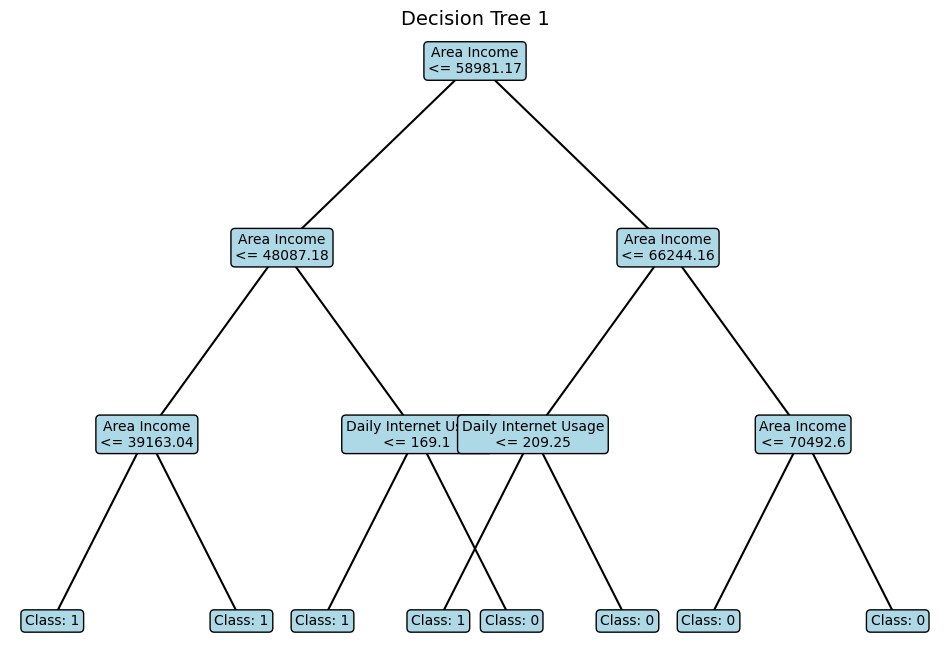

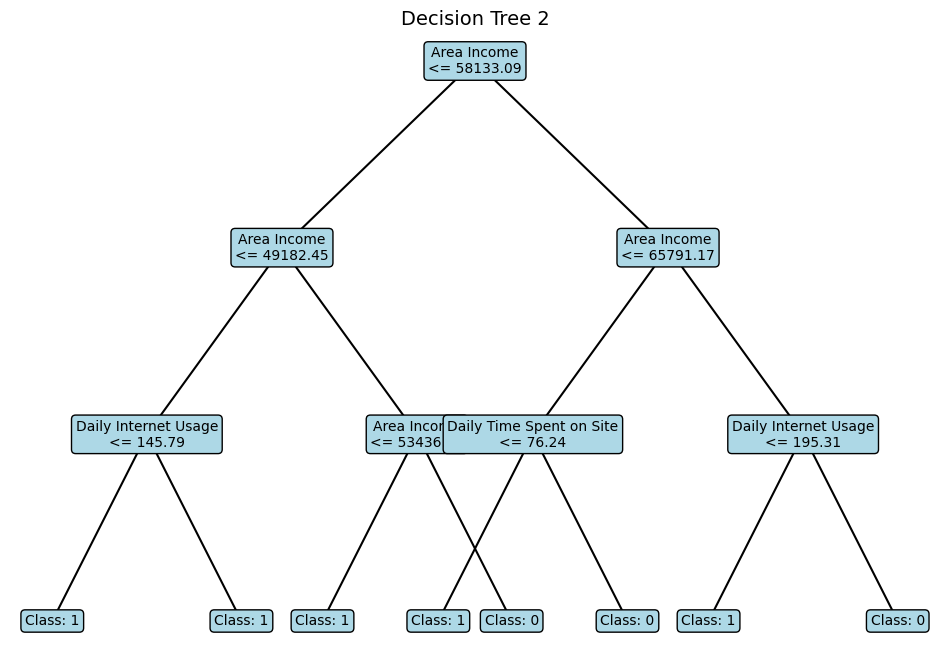

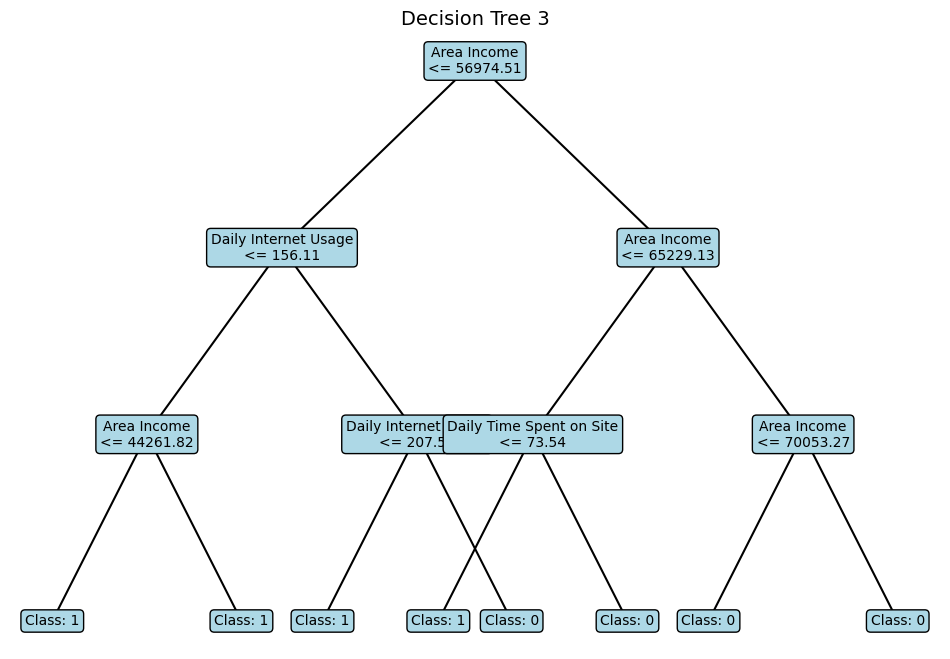

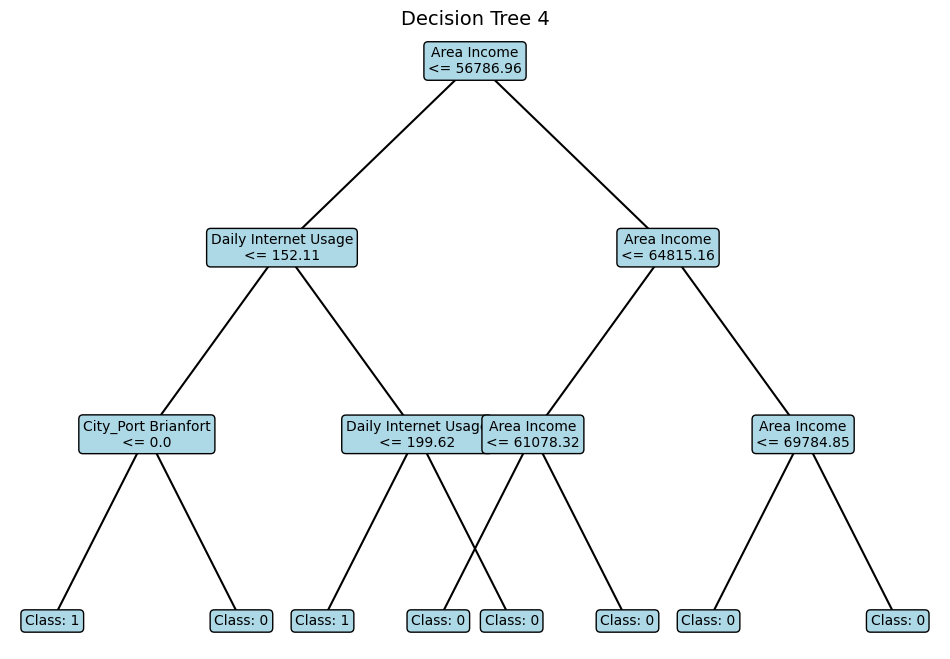

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities + 1e-9))

def gini(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)

def information_gain(X_column, y, criterion='gini'):
    total_impurity = entropy(y) if criterion == 'entropy' else gini(y)
    values, counts = np.unique(X_column, return_counts=True)
    weighted_impurity = np.sum([
        (counts[i] / len(y)) * (entropy(y[X_column == values[i]]) if criterion == 'entropy' else gini(y[X_column == values[i]]))
        for i in range(len(values))
    ])
    return total_impurity - weighted_impurity

def best_split(X, y, n_features=None, criterion='gini'):
    features = X.columns if n_features is None else np.random.choice(X.columns, n_features, replace=False)
    gains = {col: information_gain(X[col], y, criterion) for col in features}
    return max(gains, key=gains.get)

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5, n_features=None, min_samples_split=2, min_samples_leaf=1, criterion='gini'):
    if len(np.unique(y)) == 1 or depth >= max_depth or len(X) < min_samples_split:
        return Node(value=y.mode()[0])
    best_feature = best_split(X, y, n_features, criterion)
    threshold = X[best_feature].median()
    left_indices = X[best_feature] <= threshold
    right_indices = X[best_feature] > threshold
    if left_indices.sum() < min_samples_leaf or right_indices.sum() < min_samples_leaf:
        return Node(value=y.mode()[0])
    left = build_tree(X[left_indices].reset_index(drop=True), y[left_indices].reset_index(drop=True), depth+1, max_depth, n_features, min_samples_split, min_samples_leaf, criterion)
    right = build_tree(X[right_indices].reset_index(drop=True), y[right_indices].reset_index(drop=True), depth+1, max_depth, n_features, min_samples_split, min_samples_leaf, criterion)
    return Node(feature=best_feature, threshold=threshold, left=left, right=right)

def predict_tree(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

def bootstrap_sample(X, y, max_samples=None):
    n_samples = max_samples or len(y)
    indices = np.random.choice(range(len(y)), size=n_samples, replace=True)
    oob_indices = list(set(range(len(y))) - set(indices))
    return X.iloc[indices].reset_index(drop=True), y.iloc[indices].reset_index(drop=True), oob_indices

class RandomForest:
    def __init__(self, n_trees=5, max_depth=5, max_features=None, min_samples_split=2, min_samples_leaf=1, criterion='gini', oob_score=False, max_samples=None, random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        self.oob_score = oob_score
        self.max_samples = max_samples
        self.random_state = random_state
        self.trees = []
        self.oob_score_ = None
        if random_state:
            np.random.seed(random_state)
    
    def fit(self, X, y):
        if isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                n_features = int(np.sqrt(X.shape[1]))
            elif self.max_features == 'log2':
                n_features = int(np.log2(X.shape[1]))
            else:
                raise ValueError(f"Invalid max_features value: {self.max_features}")
        elif self.max_features is None:
            n_features = X.shape[1]
        else:
            n_features = int(self.max_features)

        oob_votes = np.zeros((len(y), self.n_trees))
        oob_counts = np.zeros(len(y))

        for i in range(self.n_trees):
            X_sample, y_sample, oob_indices = bootstrap_sample(X, y, self.max_samples)
            tree = build_tree(X_sample, y_sample, max_depth=self.max_depth, n_features=n_features, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, criterion=self.criterion)
            self.trees.append(tree)

            if self.oob_score:
                for idx in oob_indices:
                    pred = predict_tree(tree, X.iloc[idx])
                    oob_votes[idx, i] = pred
                    oob_counts[idx] += 1

        if self.oob_score:
            final_oob_preds = []
            for i in range(len(y)):
                if oob_counts[i] > 0:
                    votes = oob_votes[i, oob_votes[i, :] != 0]
                    if len(votes) > 0:
                        final_pred = np.bincount(votes.astype(int)).argmax()
                        final_oob_preds.append(final_pred)
                    else:
                        final_oob_preds.append(np.nan)
                else:
                    final_oob_preds.append(np.nan)
            valid_oob = ~np.isnan(final_oob_preds)
            if valid_oob.sum() > 0:
                self.oob_score_ = accuracy_score(y[valid_oob], np.array(final_oob_preds)[valid_oob])
                print(f"OOB Score: {self.oob_score_:.4f}")
            else:
                print("No valid OOB samples for scoring.")

    def predict(self, X):
        tree_preds = np.array([X.apply(lambda row: predict_tree(tree, row), axis=1) for tree in self.trees])
        predictions = []
        for i in range(tree_preds.shape[1]):
            counts = np.bincount(tree_preds[:, i].astype(int))
            if counts.size > 0:
                predictions.append(counts.argmax())
            else:
                predictions.append(0)  
        return np.array(predictions)


def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print("Performance Metrics:")
    print(f"Accuracy:            {accuracy:.4f}")
    print(f"Precision (Weighted): {precision_weighted:.4f}")
    print(f"Recall (Weighted):    {recall_weighted:.4f}")
    print(f"F1 Score (Weighted):  {f1_weighted:.4f}")

def plot_tree_matplotlib(node, ax, x=0.5, y=1.0, x_offset=0.3, y_offset=0.15):
    if node is None:
        return

    if node.value is not None:
        node_text = f"Class: {node.value}"
    else:
        if node.threshold == 0.5 and ('_' in node.feature):
            node_text = f"Is {node.feature}?"
        else:
            threshold_display = round(node.threshold, 2) if isinstance(node.threshold, (int, float)) else node.threshold
            node_text = f"{node.feature}\n<= {threshold_display}"

    bbox_props = dict(boxstyle="round,pad=0.3", fc="lightblue", ec="black", lw=1)
    ax.text(x, y, node_text, ha="center", va="center", bbox=bbox_props)

    if node.left:
        x_left = x - x_offset
        y_child = y - y_offset
        ax.plot([x, x_left], [y, y_child], 'k-')
        plot_tree_matplotlib(node.left, ax, x_left, y_child, x_offset * 0.7, y_offset)

    if node.right:
        x_right = x + x_offset
        y_child = y - y_offset
        ax.plot([x, x_right], [y, y_child], 'k-')
        plot_tree_matplotlib(node.right, ax, x_right, y_child, x_offset * 0.7, y_offset)

df = pd.read_csv("advertising.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df.drop(columns=['Timestamp'], inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols)

X = df_encoded.drop(columns=["Clicked on Ad"])
y = df_encoded["Clicked on Ad"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rf = RandomForest(n_trees=4, max_depth=3, max_features=None, min_samples_split=4, min_samples_leaf=2, criterion='gini', oob_score=True, max_samples=None, random_state=0)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred)

for idx, tree in enumerate(rf.trees):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_title(f"Decision Tree {idx + 1}", fontsize=14)
    plot_tree_matplotlib(tree, ax)
    ax.axis('off')
    plt.show()


# Q2) Apply your Random Forest Classifier on another dataset of your choice. Make changes to the hyperparameters and observe the changes in performance metrics. Plot the individual trees. 

# Solution:

OOB Score: 0.6884
Performance Metrics:
Accuracy:            0.8860
Precision (Weighted): 0.8943
Recall (Weighted):    0.8860
F1 Score (Weighted):  0.8868


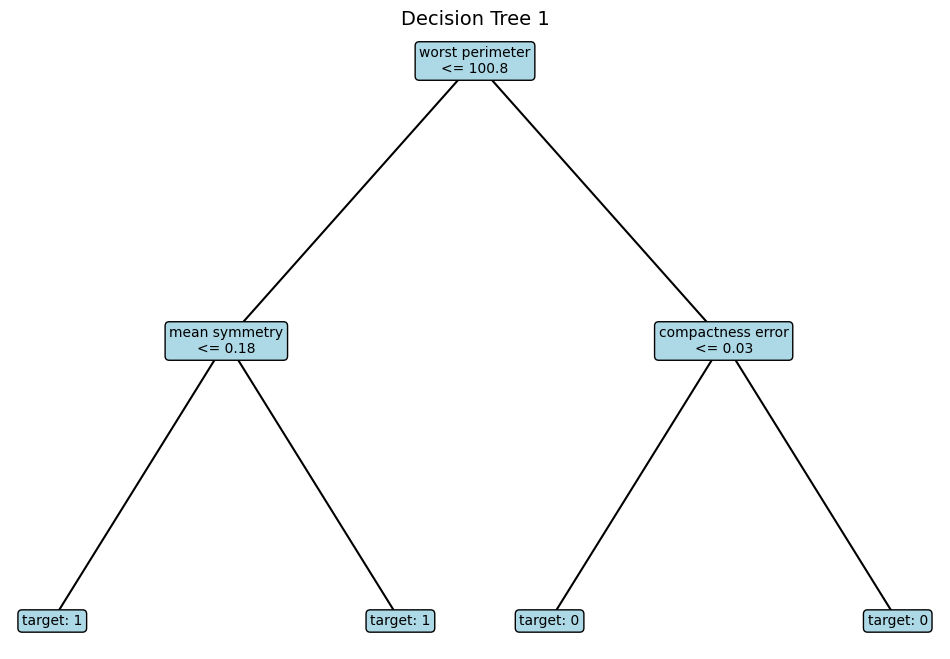

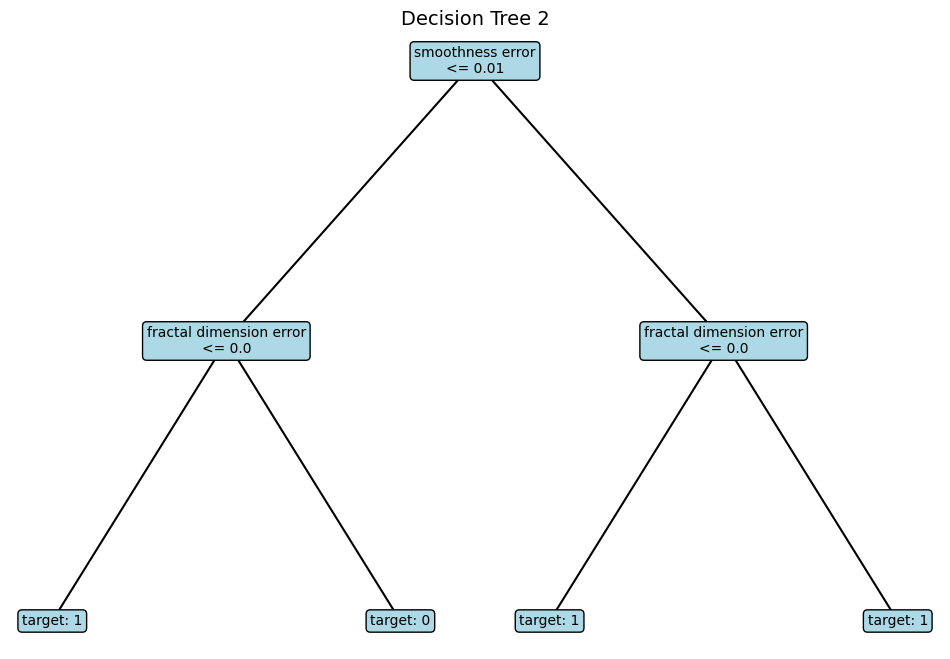

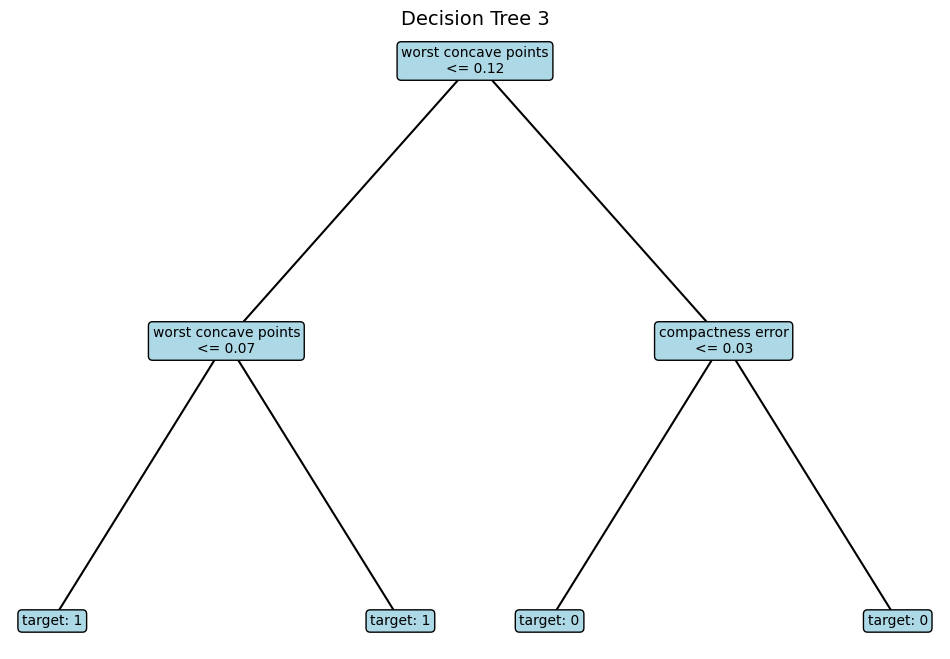

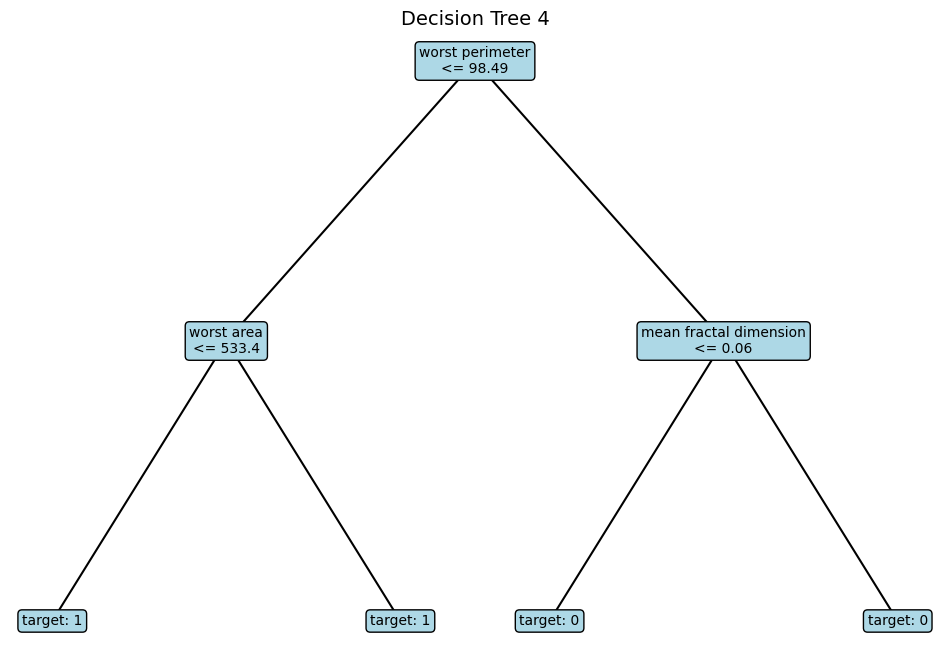

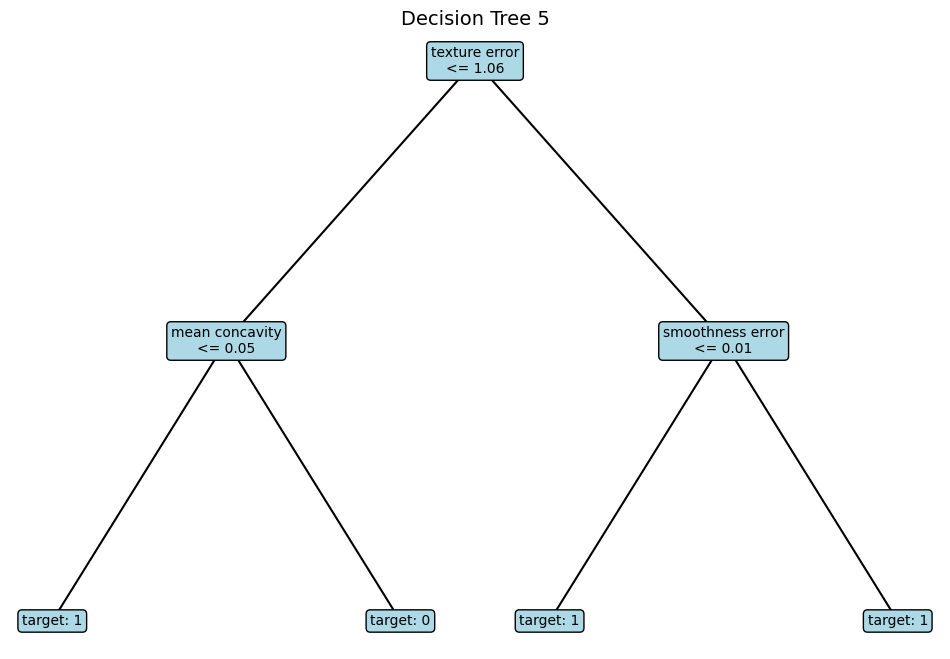

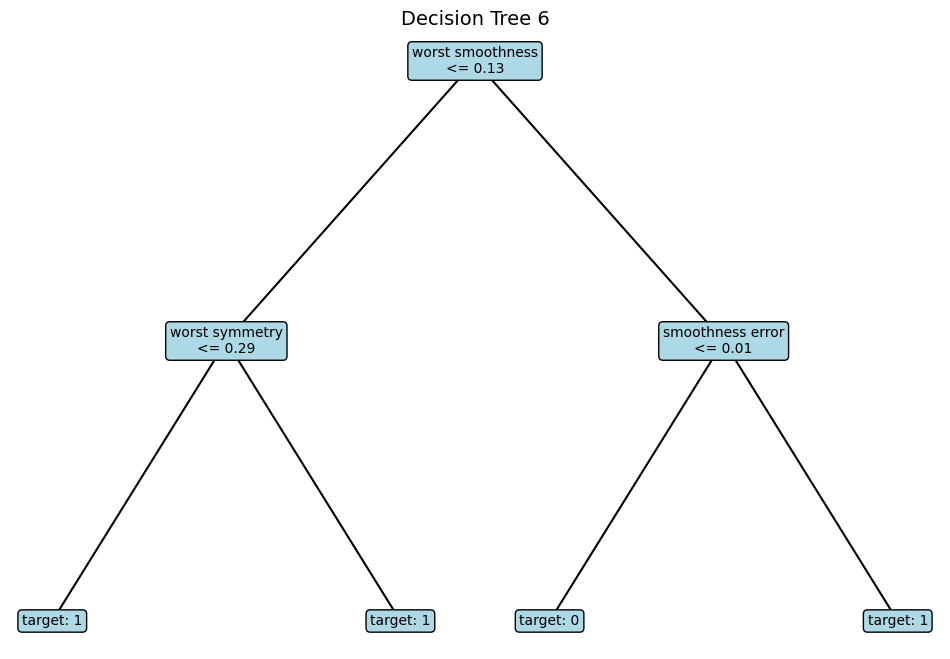

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities + 1e-9))

def gini(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)

def information_gain(X_column, y, criterion='gini'):
    total_impurity = entropy(y) if criterion == 'entropy' else gini(y)
    values, counts = np.unique(X_column, return_counts=True)
    weighted_impurity = np.sum([
        (counts[i] / len(y)) * (entropy(y[X_column == values[i]]) if criterion == 'entropy' else gini(y[X_column == values[i]]))
        for i in range(len(values))
    ])
    return total_impurity - weighted_impurity

def best_split(X, y, n_features=None, criterion='gini'):
    features = X.columns if n_features is None else np.random.choice(X.columns, n_features, replace=False)
    gains = {col: information_gain(X[col], y, criterion) for col in features}
    return max(gains, key=gains.get)

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def build_tree(X, y, depth=0, max_depth=5, n_features=None, min_samples_split=2, min_samples_leaf=1, criterion='gini'):
    if len(np.unique(y)) == 1 or depth >= max_depth or len(X) < min_samples_split:
        return Node(value=y.mode()[0])
    best_feature = best_split(X, y, n_features, criterion)
    threshold = X[best_feature].median()
    left_indices = X[best_feature] <= threshold
    right_indices = X[best_feature] > threshold
    if left_indices.sum() < min_samples_leaf or right_indices.sum() < min_samples_leaf:
        return Node(value=y.mode()[0])
    left = build_tree(X[left_indices].reset_index(drop=True), y[left_indices].reset_index(drop=True), depth+1, max_depth, n_features, min_samples_split, min_samples_leaf, criterion)
    right = build_tree(X[right_indices].reset_index(drop=True), y[right_indices].reset_index(drop=True), depth+1, max_depth, n_features, min_samples_split, min_samples_leaf, criterion)
    return Node(feature=best_feature, threshold=threshold, left=left, right=right)

def predict_tree(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)

def bootstrap_sample(X, y, max_samples=None):
    n_samples = max_samples or len(y)
    indices = np.random.choice(range(len(y)), size=n_samples, replace=True)
    oob_indices = list(set(range(len(y))) - set(indices))
    return X.iloc[indices].reset_index(drop=True), y.iloc[indices].reset_index(drop=True), oob_indices

class RandomForest:
    def __init__(self, n_trees=5, max_depth=5, max_features=None, min_samples_split=2, min_samples_leaf=1, criterion='gini', oob_score=False, max_samples=None, random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.criterion = criterion
        self.oob_score = oob_score
        self.max_samples = max_samples
        self.random_state = random_state
        self.trees = []
        self.oob_score_ = None
        if random_state:
            np.random.seed(random_state)
    
    def fit(self, X, y):
        if isinstance(self.max_features, str):
            if self.max_features == 'sqrt':
                n_features = int(np.sqrt(X.shape[1]))
            elif self.max_features == 'log2':
                n_features = int(np.log2(X.shape[1]))
            else:
                raise ValueError(f"Invalid max_features value: {self.max_features}")
        elif self.max_features is None:
            n_features = X.shape[1]
        else:
            n_features = int(self.max_features)

        oob_votes = np.zeros((len(y), self.n_trees))
        oob_counts = np.zeros(len(y))

        for i in range(self.n_trees):
            X_sample, y_sample, oob_indices = bootstrap_sample(X, y, self.max_samples)
            tree = build_tree(X_sample, y_sample, max_depth=self.max_depth, n_features=n_features, min_samples_split=self.min_samples_split, min_samples_leaf=self.min_samples_leaf, criterion=self.criterion)
            self.trees.append(tree)

            if self.oob_score:
                for idx in oob_indices:
                    pred = predict_tree(tree, X.iloc[idx])
                    oob_votes[idx, i] = pred
                    oob_counts[idx] += 1

        if self.oob_score:
            final_oob_preds = []
            for i in range(len(y)):
                if oob_counts[i] > 0:
                    votes = oob_votes[i, oob_votes[i, :] != 0]
                    if len(votes) > 0:
                        final_pred = np.bincount(votes.astype(int)).argmax()
                        final_oob_preds.append(final_pred)
                    else:
                        final_oob_preds.append(np.nan)
                else:
                    final_oob_preds.append(np.nan)
            valid_oob = ~np.isnan(final_oob_preds)
            if valid_oob.sum() > 0:
                self.oob_score_ = accuracy_score(y[valid_oob], np.array(final_oob_preds)[valid_oob])
                print(f"OOB Score: {self.oob_score_:.4f}")
            else:
                print("No valid OOB samples for scoring.")

    def predict(self, X):
        tree_preds = np.array([X.apply(lambda row: predict_tree(tree, row), axis=1) for tree in self.trees])
        predictions = []
        for i in range(tree_preds.shape[1]):
            counts = np.bincount(tree_preds[:, i].astype(int))
            if counts.size > 0:
                predictions.append(counts.argmax())
            else:
                predictions.append(0) 
        return np.array(predictions)


def evaluate_model(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print("Performance Metrics:")
    print(f"Accuracy:            {accuracy:.4f}")
    print(f"Precision (Weighted): {precision_weighted:.4f}")
    print(f"Recall (Weighted):    {recall_weighted:.4f}")
    print(f"F1 Score (Weighted):  {f1_weighted:.4f}")

def plot_tree_matplotlib(node, ax, x=0.5, y=1.0, x_offset=0.2, y_offset=0.1):
    if node is None:
        return
    if node.value is not None:
        node_text = f"target: {node.value}"
    else:
        if node.threshold == 0.5 and ('_' in node.feature):
            feature_name = node.feature
            node_text = f"Is {feature_name}?"
        else:
            threshold_display = round(node.threshold, 2) if isinstance(node.threshold, (int, float)) else node.threshold
            node_text = f"{node.feature}\n<= {threshold_display}"
    bbox_props = dict(boxstyle="round,pad=0.3", fc="lightblue", ec="black", lw=1)
    ax.text(x, y, node_text, ha="center", va="center", bbox=bbox_props)
    if node.left:
        x_left = x - x_offset
        y_child = y - y_offset
        ax.plot([x, x_left], [y, y_child], 'k-')
        plot_tree_matplotlib(node.left, ax, x_left, y_child, x_offset * 0.7, y_offset)
    if node.right:
        x_right = x + x_offset
        y_child = y - y_offset
        ax.plot([x, x_right], [y, y_child], 'k-')
        plot_tree_matplotlib(node.right, ax, x_right, y_child, x_offset * 0.7, y_offset)


df = pd.read_csv("breast_cancer_dataset.csv")
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rf = RandomForest(n_trees=6, max_depth=2, max_features='sqrt', min_samples_split=3, min_samples_leaf=3, criterion='entropy', oob_score=True, max_samples=40, random_state=15)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred)

for idx, tree in enumerate(rf.trees):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_title(f"Decision Tree {idx + 1}", fontsize=14)
    plot_tree_matplotlib(tree, ax)
    ax.axis('off')
    plt.show()
